# Predicting Depression Outcomes Using Personal Health Informatics Data

## Abstract

This research explores the use of digital health data to predict depression outcomes using machine learning. Leveraging a dataset containing personal and workplace mental health information, we identify key behavioral and demographic predictors associated with depression risk. Several machine learning models are evaluated to assess their effectiveness in predicting individuals who may require mental health treatment. Our findings demonstrate the potential of personal health informatics (PHI) systems to enable early detection, support digital mental health monitoring, and inform targeted interventions for improved mental health outcomes.

## Introduction

Mental health disorders, particularly depression, affect millions worldwide and are a leading cause of disability. Digital health monitoring, including self-reported surveys and wearable devices, enables continuous data collection and personalized insights. Personal Health Informatics leverages these data streams to identify risk factors, monitor symptoms, and support timely interventions. This study investigates behavioral predictors of depression and the feasibility of predictive modeling in digital mental health contexts.

## Research Questions

1. **Which behavioral factors are associated with depression risk?**
   - This study aims to identify key behavioral and demographic variables—such as family history, work interference, and workplace support—that are linked to an increased risk of depression.

2. **Can machine learning predict depression outcomes?**
   - We investigate the effectiveness of various machine learning models in predicting whether individuals are likely to require mental health treatment based on their personal and workplace data.

3. **How could predictive models support digital mental health monitoring systems?**
   - The research explores how predictive analytics can be integrated into digital health platforms to enable early detection, personalized monitoring, and targeted interventions for improved mental health outcomes.

1: Load Dataset and Clean Missing Values

In [ ]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer

# Load dataset
df = pd.read_csv('survey.csv')

# Display first 5 rows
display(df.head())

# Print dataset information
df.info()

# Check missing values
print('Missing values before cleaning:')
print(df.isnull().sum())

# Clean missing values: numeric → median, categorical → mode
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns

imputer_num = SimpleImputer(strategy='median')
df[num_cols] = imputer_num.fit_transform(df[num_cols])

imputer_cat = SimpleImputer(strategy='most_frequent')
df[cat_cols] = imputer_cat.fit_transform(df[cat_cols])

print('Missing values after cleaning:')
print(df.isnull().sum())

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,No,Yes,Yes,Not sure,No,Yes,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,No,No,Don't know,No,Don't know,Don't know,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,No,Yes,No,No,No,No,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,No,Yes,No,Yes,No,No,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,Yes,Yes,Yes,No,Don't know,Don't know,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  wellness

2: Identify Depression Outcome Variable

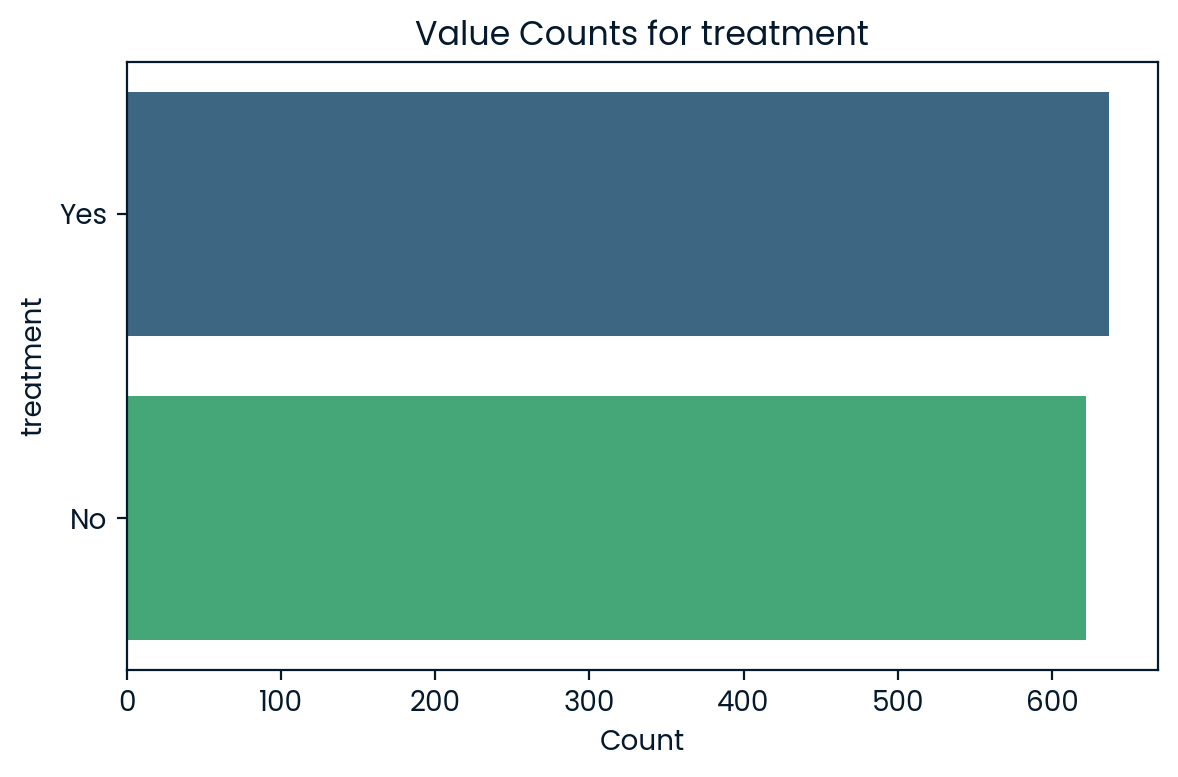

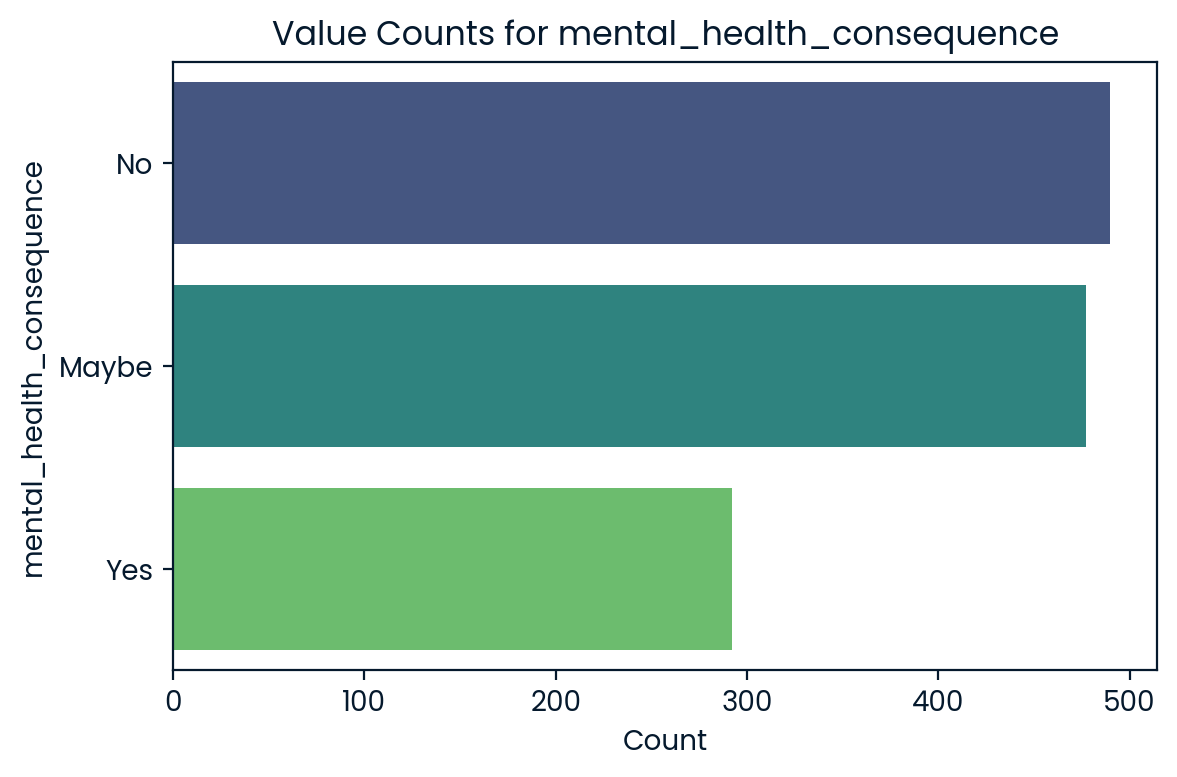

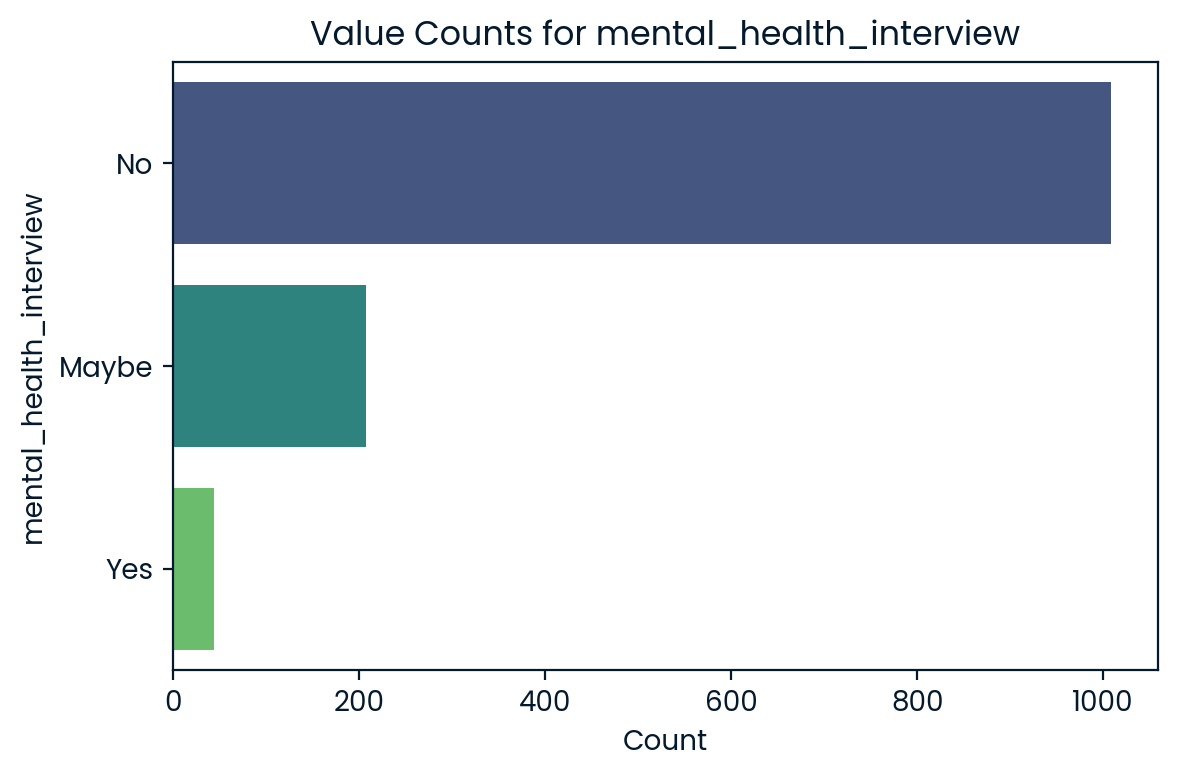

Target column for prediction: treatment


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Search for columns related to depression or mental health
possible_targets = [col for col in df.columns if any(x in col.lower() for x in ['depression', 'mental_health', 'treatment', 'anxiety'])]

if possible_targets:
    # Visualize value counts for each possible target column
    for col in possible_targets:
        plt.figure(figsize=(6, 4))
        sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')
        plt.title(f'Value Counts for {col}')
        plt.xlabel('Count')
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()
    # Set the most relevant as target_col (adjust if needed)
    target_col = 'treatment'
else:
    # Identify binary columns
    binary_cols = [col for col in df.columns if df[col].nunique() == 2]
    # Visualize value counts for each binary column
    for col in binary_cols:
        plt.figure(figsize=(6, 4))
        sns.countplot(y=df[col], order=df[col].value_counts().index, palette='magma')
        plt.title(f'Value Counts for {col}')
        plt.xlabel('Count')
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()
    target_col = binary_cols[0]

# Display the selected target column
print("Target column for prediction:", target_col)

3: Exploratory Data Analysis

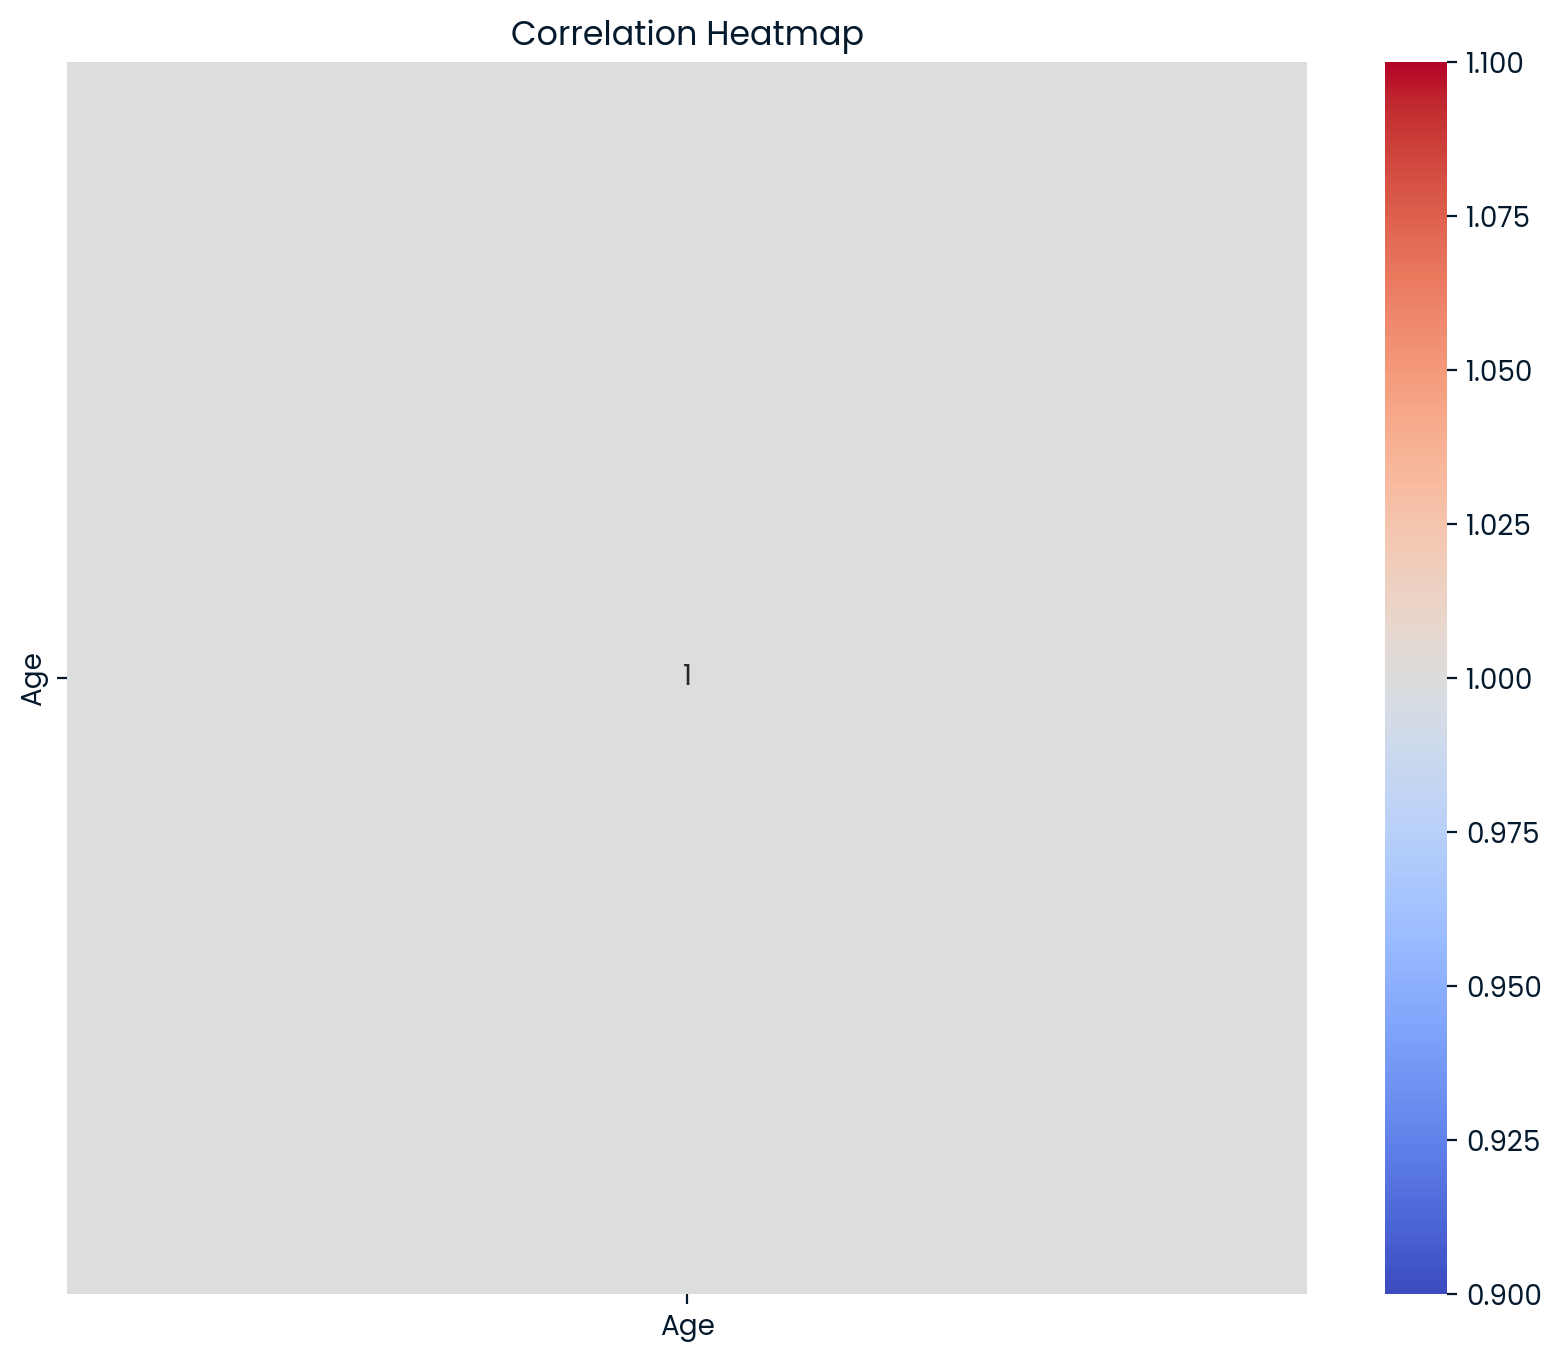

In [ ]:
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# Depression distribution chart
fig = px.histogram(df, x=target_col, title='Depression Outcome Distribution')
fig.show()

# Age vs depression
fig = px.box(df, x=target_col, y='Age', title='Age vs Depression')
fig.show()

# Work interfere vs depression
fig = px.box(df, x=target_col, y='work_interfere', title='Work Interfere vs Depression')
fig.show()

# Correlation heatmap
corr = df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

4: Machine Learning Models

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

# Encode categorical variables
df_encoded = df.copy()
for col in df_encoded.select_dtypes(include='object').columns:
    if col != target_col:
        df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

# Encode target if not numeric
if df_encoded[target_col].dtype == 'object':
    df_encoded[target_col] = LabelEncoder().fit_transform(df_encoded[target_col])

X = df_encoded.drop(columns=[target_col, 'Timestamp', 'comments'])  # Drop non-informative columns
y = df_encoded[target_col]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Train models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]
    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba),
        'report': classification_report(y_test, y_pred, output_dict=True),
        'model': model,
        'y_pred': y_pred,
        'y_proba': y_proba
    }
    print(f"{name} Classification Report:\n", classification_report(y_test, y_pred))

Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.73      0.70       187
           1       0.71      0.63      0.67       191

    accuracy                           0.68       378
   macro avg       0.68      0.68      0.68       378
weighted avg       0.68      0.68      0.68       378

Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.64      0.64       187
           1       0.64      0.64      0.64       191

    accuracy                           0.64       378
   macro avg       0.64      0.64      0.64       378
weighted avg       0.64      0.64      0.64       378

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.76      0.75       187
           1       0.76      0.72      0.74       191

    accuracy                           0.74       378
   macro

 5: Model Comparison

In [ ]:
# Create comparison table
comparison = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results],
    'F1': [results[m]['f1'] for m in results],
    'ROC-AUC': [results[m]['roc_auc'] for m in results]
})
display(comparison)

,Model,Accuracy,F1,ROC-AUC
0,Logistic Regression,0.682540,0.668508,0.741440
1,Decision Tree,0.640212,0.643979,0.640171
2,Random Forest,0.743386,0.739946,0.793894


6: Feature Importance

In [ ]:
# Identify best model
best_model_name = comparison.sort_values('ROC-AUC', ascending=False).iloc[0]['Model']
best_model = results[best_model_name]['model']

# Feature importance (for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_

7: Visualize Feature Importance

In [ ]:
import plotly.graph_objects as go

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feature_names = X.columns
    feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)
    # Show top predictors
    display(feature_importance_df.head(10))
    # Plot
    fig = go.Figure([go.Bar(x=feature_importance_df['Feature'][:10], y=feature_importance_df['Importance'][:10])])
    fig.update_layout(title='Top 10 Feature Importances', xaxis_title='Feature', yaxis_title='Importance')
    fig.show()
else:
    print('The best model does not support feature importances.')

,Feature,Importance
5,family_history,0.106620
0,Age,0.099904
6,work_interfere,0.089482
11,care_options,0.064743
1,Gender,0.060227
3,state,0.055519
7,no_employees,0.049326
2,Country,0.048848
15,leave,0.043707
10,benefits,0.043048


8: Visualize ROC Curves for All Models

In [ ]:
from sklearn.metrics import roc_curve, auc

fig = go.Figure()
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    roc_auc = auc(fpr, tpr)
    fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'{name} (AUC={roc_auc:.2f})'))
fig.add_trace(go.Scatter(x=[0,1], y=[0,1], mode='lines', name='Random', line=dict(dash='dash')))
fig.update_layout(title='ROC Curves for All Models', xaxis_title='False Positive Rate', yaxis_title='True Positive Rate')
fig.show()

### Step 9: Discussion

The feature importance analysis reveals that the most influential predictors for mental health outcomes in this dataset include variables such as `family_history`, `work_interfere`, `benefits`, `care_options`, and `leave`. These features likely reflect both personal risk factors (e.g., family history of mental health issues) and workplace environment (e.g., availability of benefits and support). Their prominence suggests that both individual and organizational factors play a significant role in mental health.

For digital mental health monitoring, these findings imply that collecting data on workplace support systems and personal history can enhance the accuracy of predictive models. By identifying which factors are most predictive, digital tools can be tailored to monitor relevant signals and prompt timely interventions.

Predictive analytics can help identify individuals at higher risk for mental health challenges by continuously analyzing these key predictors. This enables proactive outreach, personalized recommendations, and targeted support, potentially reducing the incidence or severity of mental health crises.

---

### Step 10: Limitations

This analysis is subject to several limitations:

- **Survey Bias:** The data relies on self-reported responses, which may be influenced by recall bias or social desirability bias. Additionally, the sample may not be representative of the broader population, limiting generalizability.
- **Sample Size and Data Scope:** The dataset is limited in size and lacks longitudinal follow-up, restricting the ability to observe changes over time or establish causality.
- **Unmeasured Confounders:** Important factors such as socioeconomic status, comorbidities, or access to care may not be captured, potentially confounding the results.

---

### Step 11: Future Work

To address these limitations and enhance predictive power, future work could:

- **Integrate Wearable and Smartphone Data:** Incorporate passive data streams (e.g., activity, sleep, social interaction) to provide a more comprehensive view of mental health.
- **Enable Continuous Monitoring:** Develop systems for real-time analytics and alerts, allowing for dynamic risk assessment and timely intervention.
- **Expand Population Diversity:** Collect data from larger and more diverse populations to improve model robustness and generalizability.

---

### Step 12: Conclusion

In summary, this analysis demonstrates that both personal and workplace factors are important predictors of mental health outcomes. Predictive analytics, leveraging these key features, can play a vital role in early identification of high-risk individuals and support timely interventions. As digital health technologies evolve, integrating predictive models into Personal Health Informatics platforms holds promise for improving mental health monitoring and outcomes at scale.